# FBS Detection — Extra Trees

Extra Trees (Extremely Randomized Trees) model for False Base Station detection. Part of the AI model benchmark — see `fbs_model_benchmark.ipynb` for comparative analysis of training overhead and detection performance.

In [17]:
import json
import time
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    accuracy_score,
    matthews_corrcoef,
)
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load Preprocessed Splits

Run `fbs_dataset_analysis.ipynb` first to produce `fbs_train.csv`, `fbs_test.csv`, and `fbs_class_weights.json`.

In [18]:
TRAIN_PATH = Path("fbs_train.csv")
TEST_PATH  = Path("fbs_test.csv")
CW_PATH    = Path("fbs_class_weights.json")

for p in [TRAIN_PATH, TEST_PATH]:
    if not p.exists():
        raise FileNotFoundError(
            f"Split file not found: {p}\n"
            "Run fbs_dataset_analysis.ipynb first to generate all split files."
        )

train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

feature_cols = [c for c in train_df.columns if c not in ("label", "source")]

X_train = train_df[feature_cols].values.astype(np.float32)
y_train = train_df["label"].values
X_test  = test_df[feature_cols].values.astype(np.float32)
y_test  = test_df["label"].values

cw = {int(k): v for k, v in json.load(open(CW_PATH)).items()} if CW_PATH.exists() else "balanced"

print(f"Train: {len(X_train):,} | Test: {len(X_test):,} | Features: {len(feature_cols)}")

Train: 4,171 | Test: 1,043 | Features: 762


## 2. Train Extra Trees

In [19]:
model = ExtraTreesClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=3,
    max_features="sqrt",
    class_weight=cw if isinstance(cw, dict) else "balanced",
    random_state=42,
    n_jobs=-1,
)

t0 = time.perf_counter()
model.fit(X_train, y_train)
train_time_sec = time.perf_counter() - t0
print(f"Extra Trees training complete in {train_time_sec:.2f}s")

Extra Trees training complete in 0.16s


## 3. Detection Overhead (Inference Latency)

In [20]:
n_test = len(X_test)
t0 = time.perf_counter()
y_pred = model.predict(X_test)
inference_sec = time.perf_counter() - t0
ms_per_sample = (inference_sec / n_test) * 1000
print(f"Batch inference: {inference_sec:.4f}s ({n_test} samples)")
print(f"Per-sample latency: {ms_per_sample:.4f} ms")

Batch inference: 0.0232s (1043 samples)
Per-sample latency: 0.0223 ms


## 4. Detection Quality (Evaluation)

In [21]:
y_proba = model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
mcc = matthews_corrcoef(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("=" * 55)
print("Test Set (Final)")
print("=" * 55)
print(f"  Accuracy : {acc:.4f}")
print(f"  MCC      : {mcc:.4f}")
print(f"  ROC-AUC  : {auc:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["Normal", "Attack"]))

Test Set (Final)
  Accuracy : 0.8802
  MCC      : 0.7598
  ROC-AUC  : 0.9420

              precision    recall  f1-score   support

      Normal       0.88      0.89      0.89       544
      Attack       0.88      0.87      0.87       499

    accuracy                           0.88      1043
   macro avg       0.88      0.88      0.88      1043
weighted avg       0.88      0.88      0.88      1043



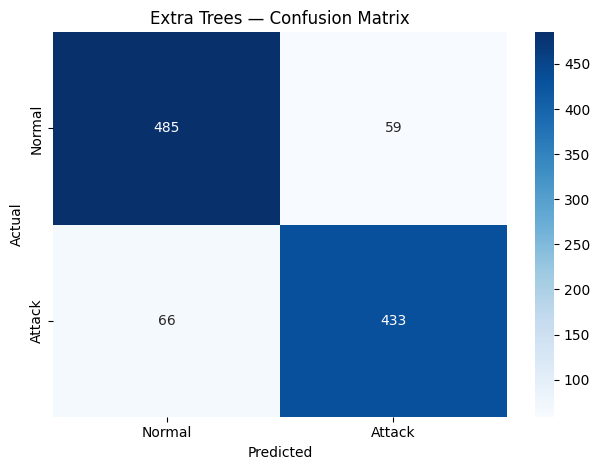

In [22]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Normal", "Attack"], yticklabels=["Normal", "Attack"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Extra Trees — Confusion Matrix")
plt.tight_layout()
plt.show()

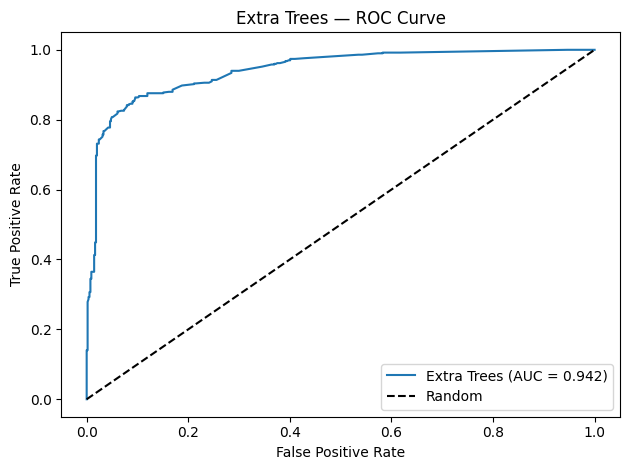

In [23]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f"Extra Trees (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Extra Trees — ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Export Metrics for Benchmark

In [24]:
from sklearn.metrics import precision_score, recall_score, f1_score

metrics = {
    "model": "Extra Trees",
    "train_time_sec": train_time_sec,
    "inference_batch_sec": inference_sec,
    "inference_ms_per_sample": ms_per_sample,
    "accuracy": acc,
    "precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
    "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
    "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
    "roc_auc": auc,
    "mcc": mcc,
}

with open("fbs_benchmark_extratrees.json", "w") as f:
    json.dump(metrics, f, indent=2)
print("Saved fbs_benchmark_extratrees.json")

Saved fbs_benchmark_extratrees.json
